A few goals:
- validate that the closed form variance calculations match the variance in the forcing
- compare the variance of the forcing at short timescales to the white noise intensity limit
- show how the forcing intensity could help constrain the continuous timescale and variance of the forcing

In [1]:
import numpy as np
import xarray as xr
from methane_noise_forcing import (
    psd_one_sided_cyclic,
    closed_form,
    calculate_mean_and_ci,
)
from methane_noise_forcing.noise import (
    solve_ch4_anomaly_lifetime,
    simulate_two_timescale_ar1,
)
from methane_noise_forcing.plotting.constants import matplotlib_rcparams, colors_vibrant
import matplotlib.pyplot as plt

plt.rcParams.update(matplotlib_rcparams)

# 1. Does closed form variance calculation match the variance in the forcing?
We're going to target a variance ($\sigma_C^2$) of 100 ppb<sup>2</sup> for the methane anomaly. Using a small time step of 0.1, we'll simulate 10 ensemble members of 1,000 years for timescales of 0.01, 0.1, 1, 10, and 100 years. We'll then calculate the variance of the methane anomaly from the simulations and compare it to the closed form calculation.

From prior work, we know that the closed form forcing variance ($\sigma_\varepsilon^2$) for a two-timescale AR(1) process is given by:
$$
\sigma_\varepsilon^2 = \sigma_C^2 \left( \frac{\tau_C + \tau_\varepsilon}{\tau_C^2 \, \tau_\varepsilon} \right)
$$

Where $\tau_C$ is the methane lifetime and $\tau_\varepsilon$ is the forcing timescale. We'll use this formula to calculate the expected variance of the forcing for each timescale and compare it to the variance calculated from the simulated methane anomaly.

In [2]:
timescales = [0.01, 0.1, 1.0, 10.0, 100]
var_C_target = 100.0  # Target variance for methane anomaly in ppb^2
n_ensemble = 100
tau_C = 10  # years
dt = 0.01  # Time step in years, works even at 1 year for short timescales due to instantaneous sampling
n_years = 1000  # years

# perform simulation
two_timescale_noise = []
for tau_eta in timescales:
    x_ens, eta_ens = simulate_two_timescale_ar1(
        tau_x=tau_C,
        tau_eta=tau_eta,
        variance_x=var_C_target,
        n_steps=int(n_years / dt),
        dt=dt,
        n_ens=n_ensemble,
    )

    # put into dataset for easier handling
    ds = xr.Dataset(
        {
            "ch4": (("ensemble", "time"), x_ens),
            "forcing": (("ensemble", "time"), eta_ens),
        },
        coords={
            "time": (("time"), np.arange(0, n_years, dt)),
            "ensemble": (("ensemble"), np.arange(n_ensemble)),
        },
    )
    # add dim for timescale to dataset
    ds = ds.expand_dims({"forcing_timescale": [tau_eta]})
    ds = ds.assign_coords({"forcing_timescale": ("forcing_timescale", [tau_eta])})

    two_timescale_noise.append(ds)

# combine all datasets into one
two_timescale_noise = xr.concat(two_timescale_noise, dim="forcing_timescale")

In [3]:
## OPTIONAL
# ensure that the variance is close to the target variance for methane anomaly,
# then scale so that ensemble mean variance matches target variance exactly
for timescale in timescales:
    var_ch4_ens = two_timescale_noise.sel(forcing_timescale=timescale).ch4.var(
        dim="time"
    )
    print(
        f"Variance of methane anomaly for forcing timescale {timescale} years: {var_ch4_ens.values.mean()} ± {var_ch4_ens.values.std()} ppb^2"
    )
    scaling_factor = np.sqrt(var_C_target / var_ch4_ens.values.mean())
    two_timescale_noise.loc[dict(forcing_timescale=timescale)] *= scaling_factor

Variance of methane anomaly for forcing timescale 0.01 years: 97.37694149646833 ± 13.541813680640635 ppb^2
Variance of methane anomaly for forcing timescale 0.1 years: 99.1319136808055 ± 14.584976003931184 ppb^2
Variance of methane anomaly for forcing timescale 1.0 years: 95.80694957201845 ± 15.593854224042335 ppb^2
Variance of methane anomaly for forcing timescale 10.0 years: 95.69352835569705 ± 20.086907285377432 ppb^2
Variance of methane anomaly for forcing timescale 100 years: 88.50340218393711 ± 40.73492258529744 ppb^2


In [4]:
# calculate curve for closed form variance calculation
timescales_closed_form = np.logspace(-2, 2, 100)
methane_to_forcing_var_ratio = (
    closed_form.calculate_two_timescale_variance_ratio_methane_to_ar1_forcing(
        tau_methane=tau_C,
        tau_forcing=timescales_closed_form,
    )
)
var_forcing_closed_form = var_C_target / methane_to_forcing_var_ratio

Text(0, 0.5, 'Variance of forcing (ppb$^2$ / year$^2$)')

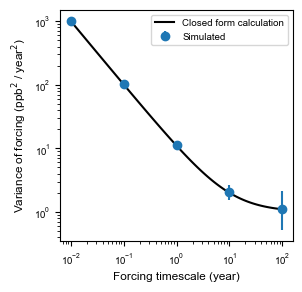

In [5]:
# plot closed form variance vs. variance from simulation for each timescale

fig, ax = plt.subplots(figsize=(3, 3))

# plot closed form variance calculation
ax.plot(
    timescales_closed_form,
    var_forcing_closed_form,
    label="Closed form calculation",
    color="black",
)

# plot variance from simulation for each timescale
for i, timescale in enumerate(timescales):
    mean, ci_low, ci_high = calculate_mean_and_ci(
        two_timescale_noise.sel(forcing_timescale=timescale).forcing.var(
            dim="time", ddof=1
        )
    )
    ax.errorbar(
        timescale,
        mean,
        yerr=[[mean - ci_low], [ci_high - mean]],
        fmt="o",
        label="Simulated" if i == 0 else None,
        color="tab:blue",
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
ax.set_xlabel("Forcing timescale (year)")
ax.set_ylabel("Variance of forcing (ppb$^2$ / year$^2$)")

The closed-form solution matches the empirical rather well regardless of if the simulations are scaled to the target variance or not, which is reassuring. 

Additionally, this confirms that the method I use can use 1-year time steps to resolve the variability of short-timescale forcings down to even 0.01 years without any issues. I presume this occurs because my method is an instantaneous sample of the underlying continuous-time process, which is not the same as sampling the continuous-time process with time averages, though I need to explore this further below.

# 2. Check for convergence of variance to white noise at short timescales
Next, we want to check if the variance of the forcing converges to the white noise limit. This is non-trivial because the units don't match. If the forcing was white instead of red, the variance of the forcing would be typical of the innovation variance of the AR(1) process, which is given by:
$$
\sigma_\varepsilon^2 = \sigma_C^2 \left( \frac{2}{\tau_C} \right)
$$
Note how the units of the variance are ppb<sup>2</sup>/year, which is different from the units of the variance of the forcing for a two-timescale process, which is ppb<sup>2</sup>/year<sup>2</sup>.

Because the methane lifetime is in essence a low-pass filter, we expect that any forcing of a short-enough timescale will be essentially "white" to methane oxidation, and thus the forcing "intensity" should converge to the white noise limit as the forcing timescale approaches zero. The Fourier transform for the red-noise forcing is calculated as follows (in angular frequency space):
$$
S_\varepsilon(\omega) = \int_{-\infty}^{\infty} R_\varepsilon(\tau) e^{-i \omega \tau} d\tau = \frac{2 \, \sigma_\varepsilon^2 \, \tau_\varepsilon}{1 + \omega^2 \, \tau_\varepsilon^2}
$$
Where $R_\varepsilon(\tau)$ is the autocovariance of the forcing $\sigma_\varepsilon^2 \exp(-|\tau|/\tau_\varepsilon)$, and $\omega$ is the angular frequency.

At short enough timescales (essentially white noise), the Fourier transform of the forcing should converge to the white noise limit, which is given by:
$$
S_\varepsilon(0) = 2 \, \sigma_\varepsilon^2 \, \tau_\varepsilon
$$
Substituting the closed-form solution for the variance of the forcing and taking the limit as $\tau_\varepsilon \to 0$, we find that the forcing intensity converges to the white noise limit.

Since I'm using the one-sided PSD to calculate the forcing intensity, double the white noise limit to account for the fact that the one-sided PSD only includes positive frequencies.

In [6]:
## calculate fourier transform of the forcing for each timescale
psd_results = {}
for timescale in timescales:
    psd = []
    for ens in two_timescale_noise.ensemble.values:
        forcing = two_timescale_noise.sel(
            ensemble=ens, forcing_timescale=timescale
        ).forcing.values
        # freqs, power_spectrum = calculate_fourier_transform_fft(forcing, dt=dt)
        freqs, power_spectrum = psd_one_sided_cyclic(forcing, dt=dt)
        psd.append(np.abs(power_spectrum))
    psd_results[timescale] = xr.DataArray(
        data=np.array(psd),
        dims=["ensemble", "frequency"],
        coords={
            "ensemble": two_timescale_noise.ensemble.values,
            "frequency": freqs,
        },
    )
psds_empirical = xr.concat(
    [psd_results[timescale] for timescale in timescales], dim="forcing_timescale"
)
psds_empirical = psds_empirical.assign_coords(
    {"forcing_timescale": ("forcing_timescale", timescales)}
)

In [7]:
## colors of the lines for each timescale in the PSD plot
colors = {
    0.01: colors_vibrant["blue"],
    0.1: colors_vibrant["orange"],
    1.0: colors_vibrant["grey"],
    10.0: colors_vibrant["red"],
    100.0: colors_vibrant["cyan"],
}

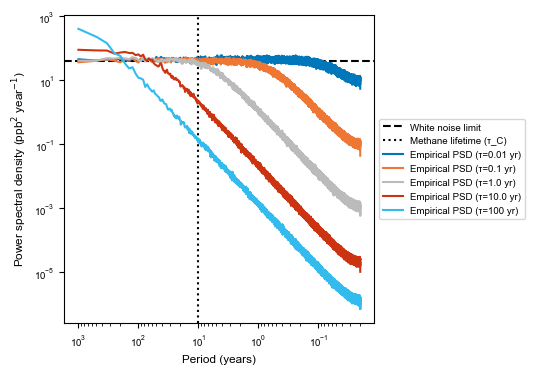

In [8]:
## plot empirical PSD against white noise limit
fig, ax = plt.subplots(figsize=(4, 4))
# white noise
var_innovation = var_C_target * 2 / tau_C * 2  # factor of 2 for one-sided PSD
ax.axhline(var_innovation, color="k", linestyle="--", label="White noise limit")
ax.axvline(tau_C, color="k", linestyle=":", label="Methane lifetime (τ_C)")

for timescale in timescales:
    psd = psds_empirical.sel(forcing_timescale=timescale)
    # plot every 10 points to avoid cluttering the plot too much
    ax.plot(
        1 / psd.frequency,
        psd.mean(dim="ensemble"),
        label=f"Empirical PSD (τ={timescale} yr)",
        color=colors[timescale],
    )
ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_xaxis()

ax.set_xlabel("Period (years)")
ax.set_ylabel("Power spectral density (ppb$^2$ year$^{-1}$)")
# legend on outside right side of the plot
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

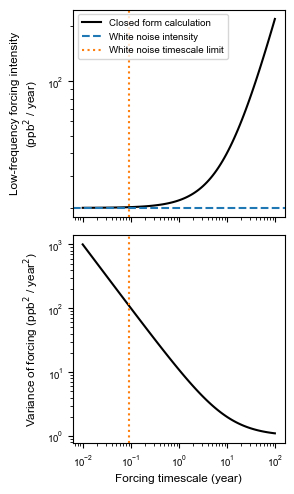

In [9]:
## plot forcing intensity vs. timescale for closed-form calculations
intensity_closed_form = var_forcing_closed_form * 2 * timescales_closed_form
white_noise_intensity = var_C_target * 2 / tau_C

# calculate when white noise intensity is less than 1% different from closed form intensity calculation
tolerance = 0.01 * intensity_closed_form
mask = np.abs(intensity_closed_form - white_noise_intensity) < tolerance
timescale_limit = timescales_closed_form[mask][-1]

fig, axs = plt.subplots(2, 1, figsize=(3, 5), sharex=True)

# plot closed form intensity calculation
axs[0].plot(
    timescales_closed_form,
    intensity_closed_form,
    label="Closed form calculation",
    color="black",
)
axs[0].axhline(
    white_noise_intensity,
    color="tab:blue",
    linestyle="--",
    label="White noise intensity",
)
axs[0].axvline(
    timescale_limit,
    color="tab:orange",
    linestyle=":",
    label="White noise timescale limit",
)
axs[0].legend()

axs[0].set_yscale("log")
axs[0].set_ylabel("Low-frequency forcing intensity\n(ppb$^2$ / year)")

# plot closed form variance calculation
axs[1].plot(
    timescales_closed_form,
    var_forcing_closed_form,
    label="Closed form calculation",
    color="black",
)
axs[1].axvline(
    timescale_limit,
    color="tab:orange",
    linestyle=":",
    label="White noise timescale limit",
)

axs[1].set_xscale("log")
axs[1].set_yscale("log")
axs[1].set_xlabel("Forcing timescale (year)")
axs[1].set_ylabel("Variance of forcing (ppb$^2$ / year$^2$)")

plt.tight_layout()

# 3. How does averaging affect the forcing intensity and the variance of the forcing?
Practically, outputs from GCMs are often averaged over time periods longer than the forcing timescale, which can make the continuous timescale and the forcing variance difficult to interpret. This is definitely true for cases where the averaging timescale is longer than the forcing timescale, but it's unclear how this affects the interpretation of the forcing intensity and variance when the averaging timescale is shorter than or similar to the forcing timescale.

Averaging at time steps of $\Delta$ is a filter on the forcing:
$$
H(\omega) = \exp (-i \omega \Delta / 2) \frac{\sin(\omega \Delta / 2)}{\omega \Delta / 2} = \exp (-i \omega \Delta / 2) \, \text{sinc}(\omega \Delta / 2)
$$

$|H(\omega)|^2$ is the power response of the averaging filter. At $\omega = 0$, the power response is equal to 1, meaning that the averaging filter does not affect the forcing intensity at zero frequency, so $S_\varepsilon(0)$ should remain unchanged.

As $\omega$ increases, the power response decreases, meaning that the averaging filter attenuates higher frequencies more than lower frequencies. It will be important to see how this affects the timescale of the forcing intensity when the averaging timescale is similar to or shorter than the forcing timescale.

If the timescale can be recovered somewhat reliably, it'll be important to see if we can recover the variance of the continuous-time forcing from the variance of the averaged forcing.

In [10]:
## functions for fitting autocorrelation on the data and averaging the data to a certain timescale


def _ar1_phi_ols(x):
    """
    Estimate AR(1) coefficient phi and its standard error via OLS:
        x_t = c + phi * x_{t-1} + e_t
    Returns (phi_hat, se_phi, n_eff).
    """
    # drop NaNs and require at least 3 points
    x = np.asarray(x, dtype=float)
    mask = np.isfinite(x)
    x = x[mask]
    n = x.size
    if n < 3:
        return np.nan, np.nan, 0

    y = x[1:]
    X = x[:-1]
    n_eff = y.size  # number of paired samples

    # Design matrix with intercept
    A = np.column_stack([X, np.ones_like(X)])

    # OLS fit
    beta, residuals, rank, s = np.linalg.lstsq(A, y, rcond=None)
    phi_hat = float(beta[0])

    # Residual variance
    if residuals.size == 0:
        # perfectly collinear (e.g., constant series) → undefined
        return np.nan, np.nan, n_eff
    rss = float(residuals[0])
    dof = max(n_eff - 2, 1)
    sigma2 = rss / dof

    # Var(beta) = sigma2 * (A^T A)^{-1}
    ATA_inv = np.linalg.inv(A.T @ A)
    var_phi = sigma2 * ATA_inv[0, 0]
    se_phi = float(np.sqrt(var_phi))

    return phi_hat, se_phi, n_eff


def ar1_timescale(x, dt=1.0, ci=0.95):
    """
    E-folding timescale tau = -dt / ln(phi) for an AR(1), with a delta-method CI.
    Returns (tau, ci_low, ci_high). For phi <= 0 (no monotone decay),
    returns (nan, nan, nan).
    """
    phi, se_phi, n = _ar1_phi_ols(x)
    if not np.isfinite(phi):
        return np.nan, np.nan, np.nan

    # Clip phi to the open interval (-1, 1) for stability of transforms
    eps = 1e-12
    phi = float(np.clip(phi, -1 + eps, 1 - eps))

    # Define tau only for phi in (0, 1)
    if not (0 < phi < 1):
        return np.nan, np.nan, np.nan

    tau = -dt / np.log(phi)

    # Delta method: tau(phi) = -dt / ln(phi)
    # d tau / d phi = -dt / (phi * (ln(phi))^2)
    d_tau_d_phi = -dt / (phi * (np.log(phi) ** 2))
    se_tau = abs(d_tau_d_phi) * se_phi

    # z for CI
    from scipy.stats import norm

    z = norm.ppf(0.5 + ci / 2.0)
    ci_low = tau - z * se_tau
    ci_high = tau + z * se_tau

    return float(tau), float(ci_low), float(ci_high)


def ar1_timescale_xarray(data, dt=1.0, time_dim="time", ci=0.95):
    """
    Estimate AR(1) e-folding timescale and CI along `time_dim` for each series.
    Works for DataArray or Dataset. Returns a DataArray/Dataset with a new
    'ar1_stats' dimension: ['tau', 'ci_low', 'ci_high'].
    """

    def _wrapper(x):
        tau, lo, hi = ar1_timescale(x, dt=dt, ci=ci)
        return np.array([tau, lo, hi], dtype=float)

    if isinstance(data, xr.DataArray):
        # Ensure the time dim exists
        if time_dim not in data.dims:
            raise ValueError(f"time_dim '{time_dim}' not found in data.dims")

        out = xr.apply_ufunc(
            _wrapper,
            data,
            input_core_dims=[[time_dim]],
            output_core_dims=[["ar1_stats"]],
            output_sizes={"ar1_stats": 3},
            vectorize=True,
            dask="parallelized",
            output_dtypes=[float],
        )
        out = out.assign_coords(ar1_stats=["tau", "ci_low", "ci_high"])
        return out

    elif isinstance(data, xr.Dataset):
        variables = [
            v
            for v in data.data_vars
            if time_dim in data[v].dims and np.issubdtype(data[v].dtype, np.number)
        ]
        mapped = {
            v: ar1_timescale_xarray(data[v], dt=dt, time_dim=time_dim, ci=ci)
            for v in variables
        }
        return xr.Dataset(mapped)

    else:
        raise TypeError("Input must be an xarray DataArray or Dataset.")


def average_to_resolution(data, resolution, time_dim="time"):
    """
    Average data along the time dimension to the specified resolution (in years).
    Assumes time coordinate is float years.
    Returns a new DataArray or Dataset with averaged data.
    """
    time = data[time_dim].values
    # Find bin edges
    min_time = time.min()
    max_time = time.max()
    bins = np.arange(min_time, max_time + resolution, resolution)
    # Bin labels: use left edge of each bin
    bin_labels = bins[:-1]
    # Group by bin index and average
    data_grouped = data.groupby_bins(time_dim, bins, labels=bin_labels).mean(
        dim=time_dim
    )
    # Rename the new time dimension to 'time' for consistency
    data_grouped = data_grouped.rename({f"{time_dim}_bins": time_dim})
    return data_grouped

/tmp/ipykernel_1881699/965350665.py:93: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  out = xr.apply_ufunc(


Text(0, 0.5, 'Estimated timescale (yr)')

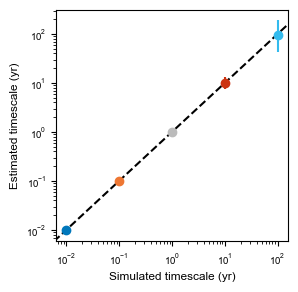

In [11]:
## validate the simulated timescale of the forcing
simulated_timescales = ar1_timescale_xarray(two_timescale_noise.forcing, dt=dt).sel(
    ar1_stats="tau"
)

# plot simulated vs actual timescale
fig, ax = plt.subplots(figsize=(3, 3))

for timescale in timescales:
    sim_timescale = simulated_timescales.sel(forcing_timescale=timescale)
    mean, ci_low, ci_high = calculate_mean_and_ci(sim_timescale)
    ax.errorbar(
        timescale,
        mean,
        yerr=[[mean - ci_low], [ci_high - mean]],
        fmt="o",
        label=f"τ={timescale} yr",
        color=colors[timescale],
    )

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlim(ax.get_xlim()[0], ax.get_xlim()[1])
ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1])

# plot 1:1 line
ax.plot([0.001, 1000], [0.001, 1000], color="k", linestyle="--", label="1:1 line")

ax.set_xlabel("Simulated timescale (yr)")
ax.set_ylabel("Estimated timescale (yr)")

Text(0, 0.5, 'Forcing anomaly (ppb/year)')

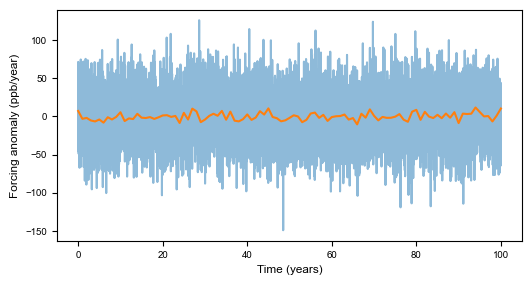

In [12]:
## validate the average_to_resolution function
two_timescale_noise_avg = average_to_resolution(
    two_timescale_noise, resolution=1.0, time_dim="time"
)

# plot 1 ensemble member and its averaged version
idx_ens = 0
timescale = 0.01
time_slice = slice(0, 100)  # first 100 years
fig, ax = plt.subplots(figsize=(6, 3))
time = two_timescale_noise.sel(time=time_slice).time.values
forcing = two_timescale_noise.sel(
    ensemble=idx_ens, forcing_timescale=timescale, time=time_slice
).forcing.values
time_avg = two_timescale_noise_avg.sel(time=time_slice).time.values
forcing_avg = two_timescale_noise_avg.sel(
    ensemble=idx_ens, forcing_timescale=timescale, time=time_slice
).forcing.values
ax.plot(time, forcing, label="Original", color="tab:blue", alpha=0.5)
ax.plot(time_avg, forcing_avg, label="Averaged", color="tab:orange")
ax.set_xlabel("Time (years)")
ax.set_ylabel("Forcing anomaly (ppb/year)")

/tmp/ipykernel_1881699/965350665.py:93: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  out = xr.apply_ufunc(


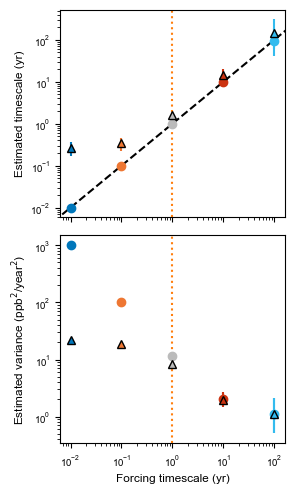

In [13]:
## calculate new timescales, and compare old vs. new variance
simulated_timescales_avg = ar1_timescale_xarray(
    two_timescale_noise_avg.forcing, dt=1.0
).sel(ar1_stats="tau")
# variance
var_forcing = two_timescale_noise.forcing.var(dim="time", ddof=1)
var_forcing_avg = two_timescale_noise_avg.forcing.var(dim="time", ddof=1)

## plots
fig, axs = plt.subplots(2, 1, figsize=(3, 5), sharex=True)

for timescale in timescales:
    sim_timescale = simulated_timescales.sel(forcing_timescale=timescale)
    mean, ci_low, ci_high = calculate_mean_and_ci(sim_timescale)
    axs[0].errorbar(
        timescale,
        mean,
        yerr=[[mean - ci_low], [ci_high - mean]],
        fmt="o",
        label=f"τ={timescale} yr",
        color=colors[timescale],
    )

    mean_avg, ci_low_avg, ci_high_avg = calculate_mean_and_ci(
        simulated_timescales_avg.sel(forcing_timescale=timescale)
    )
    axs[0].errorbar(
        timescale,
        mean_avg,
        yerr=[[mean_avg - ci_low_avg], [ci_high_avg - mean_avg]],
        fmt="^",
        label=f"τ={timescale} yr",
        color=colors[timescale],
        markeredgecolor="k",
    )

axs[0].set_xscale("log")
axs[0].set_yscale("log")

axs[0].set_xlim(axs[0].get_xlim()[0], axs[0].get_xlim()[1])
axs[0].set_ylim(axs[0].get_ylim()[0], axs[0].get_ylim()[1])

# plot 1:1 line
axs[0].plot([0.001, 1000], [0.001, 1000], color="k", linestyle="--", label="1:1 line")

# vertical line for averaging timescale
axs[0].axvline(
    1.0, color="tab:orange", linestyle=":", label="Averaging timescale (1 yr)"
)

axs[0].set_ylabel("Estimated timescale (yr)")

# change in variance
for timescale in timescales:
    var_orig = var_forcing.sel(forcing_timescale=timescale)
    mean_orig, ci_low_orig, ci_high_orig = calculate_mean_and_ci(var_orig)
    var_avg = var_forcing_avg.sel(forcing_timescale=timescale)
    mean_avg, ci_low_avg, ci_high_avg = calculate_mean_and_ci(var_avg)
    axs[1].errorbar(
        timescale,
        mean_orig,
        yerr=[[mean_orig - ci_low_orig], [ci_high_orig - mean_orig]],
        fmt="o",
        label=f"τ={timescale} yr",
        color=colors[timescale],
    )
    axs[1].errorbar(
        timescale,
        mean_avg,
        yerr=[[mean_avg - ci_low_avg], [ci_high_avg - mean_avg]],
        fmt="^",
        label=f"τ={timescale} yr",
        color=colors[timescale],
        markeredgecolor="k",
    )
axs[1].set_xscale("log")
axs[1].set_yscale("log")

# vertical line for averaging timescale
axs[1].axvline(
    1.0, color="tab:orange", linestyle=":", label="Averaging timescale (1 yr)"
)

axs[1].set_ylabel("Estimated variance (ppb$^2$/year$^2$)")
axs[1].set_xlabel("Forcing timescale (yr)")

plt.tight_layout()

As expected, averaging to annual resolution biases the estimated forcing timescale high and the variance of the forcing low, especially when the averaging timescale is longer than the forcing timescale. The changes are relatively small when the averaging timescale is similar to the forcing timescale, but the bias still exists.

In [14]:
psd_results = {}
for timescale in timescales:
    psd = []
    for ens in two_timescale_noise.ensemble.values:
        forcing = two_timescale_noise.sel(
            ensemble=ens, forcing_timescale=timescale
        ).forcing.values
        freqs, power_spectrum = psd_one_sided_cyclic(forcing, dt=dt)
        psd.append(np.abs(power_spectrum))
    psd_results[timescale] = xr.DataArray(
        data=np.array(psd),
        dims=["ensemble", "frequency"],
        coords={
            "ensemble": two_timescale_noise.ensemble.values,
            "frequency": freqs,
        },
    )
psds_empirical = xr.concat(
    [psd_results[timescale] for timescale in timescales], dim="forcing_timescale"
)
psds_empirical = psds_empirical.assign_coords(
    {"forcing_timescale": ("forcing_timescale", timescales)}
)

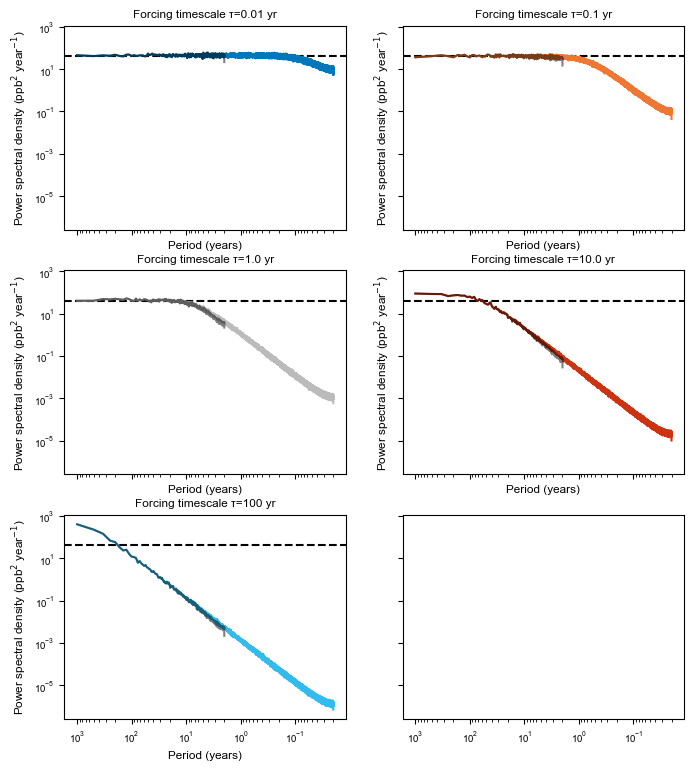

In [16]:
## calculate PSD of averaged data
psd_results_avg = {}
for timescale in timescales:
    psd = []
    for ens in two_timescale_noise_avg.ensemble.values:
        forcing = two_timescale_noise_avg.sel(
            ensemble=ens, forcing_timescale=timescale
        ).forcing.values
        freqs, power_spectrum = psd_one_sided_cyclic(forcing, dt=1.0)
        psd.append(np.abs(power_spectrum))
    psd_results_avg[timescale] = xr.DataArray(
        data=np.array(psd),
        dims=["ensemble", "frequency"],
        coords={
            "ensemble": two_timescale_noise_avg.ensemble.values,
            "frequency": freqs,
        },
    )
psds_empirical_avg = xr.concat(
    [psd_results_avg[timescale] for timescale in timescales], dim="forcing_timescale"
)
psds_empirical_avg = psds_empirical_avg.assign_coords(
    {"forcing_timescale": ("forcing_timescale", timescales)}
)

## plot averaged PSD against original PSD
#  2 columns, floor(len(timescales)/2) rows
nrows = np.ceil(len(timescales) / 2).astype(int)
fig, axs = plt.subplots(
    nrows=nrows, ncols=2, figsize=(8, 3 * nrows), sharex=True, sharey=True
)

for i, timescale in enumerate(timescales):
    ax_psd = axs.flat[i]
    # white noise
    var_innovation = var_C_target * 2 / tau_C * 2  # factor of 2 for one-sided PSD
    ax_psd.axhline(var_innovation, color="k", linestyle="--", label="White noise limit")

    psd = psds_empirical.sel(forcing_timescale=timescale)
    ax_psd.plot(
        1 / psd.frequency,
        psd.mean(dim="ensemble"),
        label=f"Empirical PSD (τ={timescale} yr)",
        color=colors[timescale],
        linestyle="-",
    )

    psd_avg = psds_empirical_avg.sel(forcing_timescale=timescale)
    ax_psd.plot(
        1 / psd_avg.frequency,
        psd_avg.mean(dim="ensemble"),
        label=f"Averaged PSD (τ={timescale} yr)",
        color="k",
        linestyle="-",
        alpha=0.5,
    )

    ax_psd.set_xscale("log")
    ax_psd.set_yscale("log")
    ax_psd.invert_xaxis()

    ax_psd.set_xlabel("Period (years)")
    ax_psd.set_ylabel("Power spectral density (ppb$^2$ year$^{-1}$)")
    ax_psd.set_title(f"Forcing timescale τ={timescale} yr")

Here, the bias is clearly a result of the nyquist frequency of the averaging filter being too low to resolve the forcing timescale. The PSD of the averaged spectrum looks really close to the original PSD when the frequency is lower than the Nyquist frequency. The timescale becomes unresolvable when the Nyquist frequency is lower than the forcing timescale, which makes sense.

What's important is that the forcing intenstiy at low frequencies is similar between the original and averaged forcings. This means:
1. for forcings near the averaging timescale, the bias in the forcing intensity is negligible even if there is a bias in the estimated forcing timescale and variance. (aka same result)
2. forcing intensity should be a good metric to compare for forcings with timescales shorter than the averaging timescale.

TODO: check that using the intensity, we can vary the forcing timescale to recover something about the original variance.